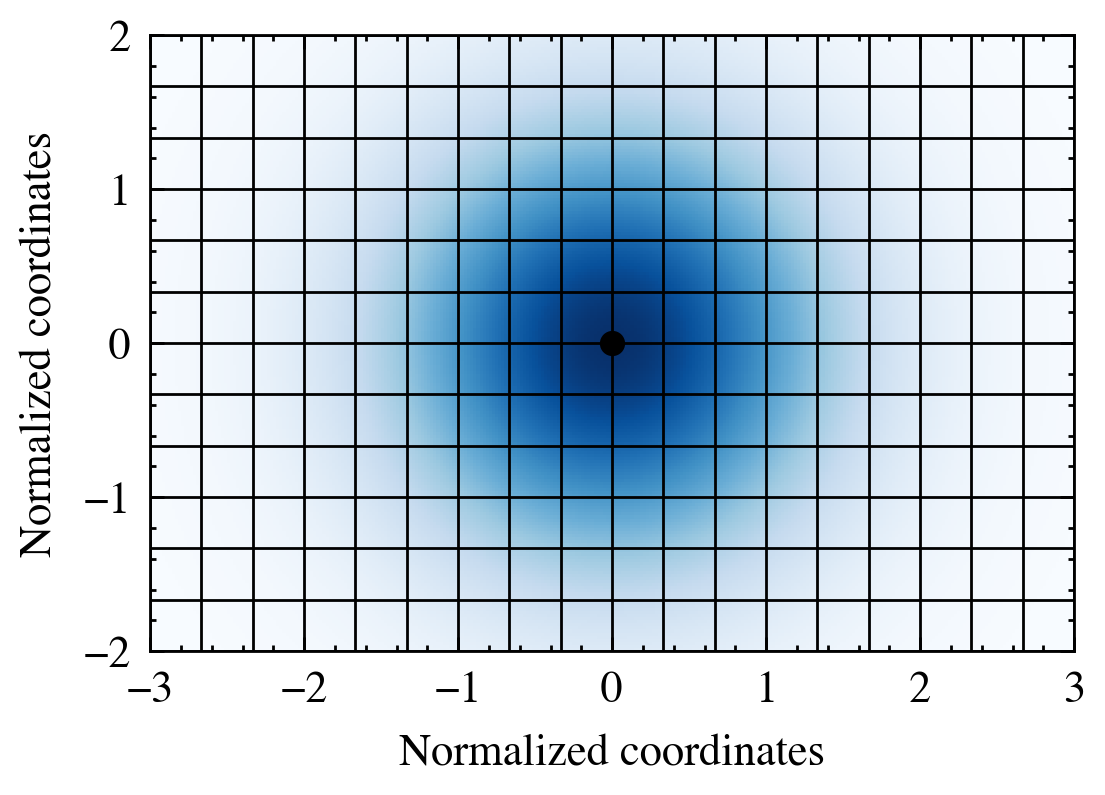

In [23]:
import matplotlib.pyplot as plt
import numpy as np

from smudgy.grid import grid_lines

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use("../../../smudgy_analysis/mnras_mpl_stylefile")

# grid
x = np.linspace(-3, 3, 300)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)

vlines, hlines, _ = grid_lines(
    edges=[x.min(), x.max(), y.min(), y.max()],
    nx=18,
    ny=12,
    include_edges=True
    )

# Gaussian kernel centered at (0, 0)
pos_center = (0.0, 0.0)
sigma = 1.0
W = np.exp(-((X-pos_center[0])**2 + (Y-pos_center[1])**2) / (2 * sigma**2))

# plot
fig, ax = plt.subplots(figsize=(3, 2))
im = ax.imshow(W, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", cmap="Blues")
plt.scatter(pos_center[0], pos_center[1], color="k", marker=".", s=50, label="center")

ax.hlines(hlines, x.min(), x.max(), color="k", linestyle="-", lw=0.5, zorder=1)
ax.vlines(vlines, y.min(), y.max(), color="k", linestyle="-", lw=0.5, zorder=1)
plt.xlabel("Normalized coordinates")
plt.ylabel("Normalized coordinates")

plt.savefig("kernel_over_grid.png", dpi=300, bbox_inches="tight", transparent=False)
plt.show()